<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/TALLERQUIZ_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Julian David Morales Pineda
## Modelado de simbolos con 2 secuencias de 0 y 1

Los símbolos están definidos de la siguiente manera:

Sacar el estimador para hacer el espectro promedio de los 64 simbolos, espectro prmedio 1/64, todos sobre 64 y poner en graficas diferentes los simbolos
de la siguiente manera:

$$
a_0 = \mathcal{N}(0, D^2)\,\frac{1}{D_1}
$$

El símbolo:

$$
a_1 = \mathcal{N}(0, D_1^2)
$$

La señal transmitida se define como:

$$
x(d_i, t) \in \{ d_i(t) : i = 0, 1 \}
$$

Esto significa que:

Si el símbolo transmitido es 0:

$$
x(d_0, t) = d_0(t)
$$

Si el símbolo transmitido es 1:

$$
x(d_1, t) = d_1(t)
$$

En resumen, la señal transmitida en cada instante pertenece al conjunto:

$$
\{ d_0(t),\ d_1(t) \}
$$

dependiendo del símbolo enviado.




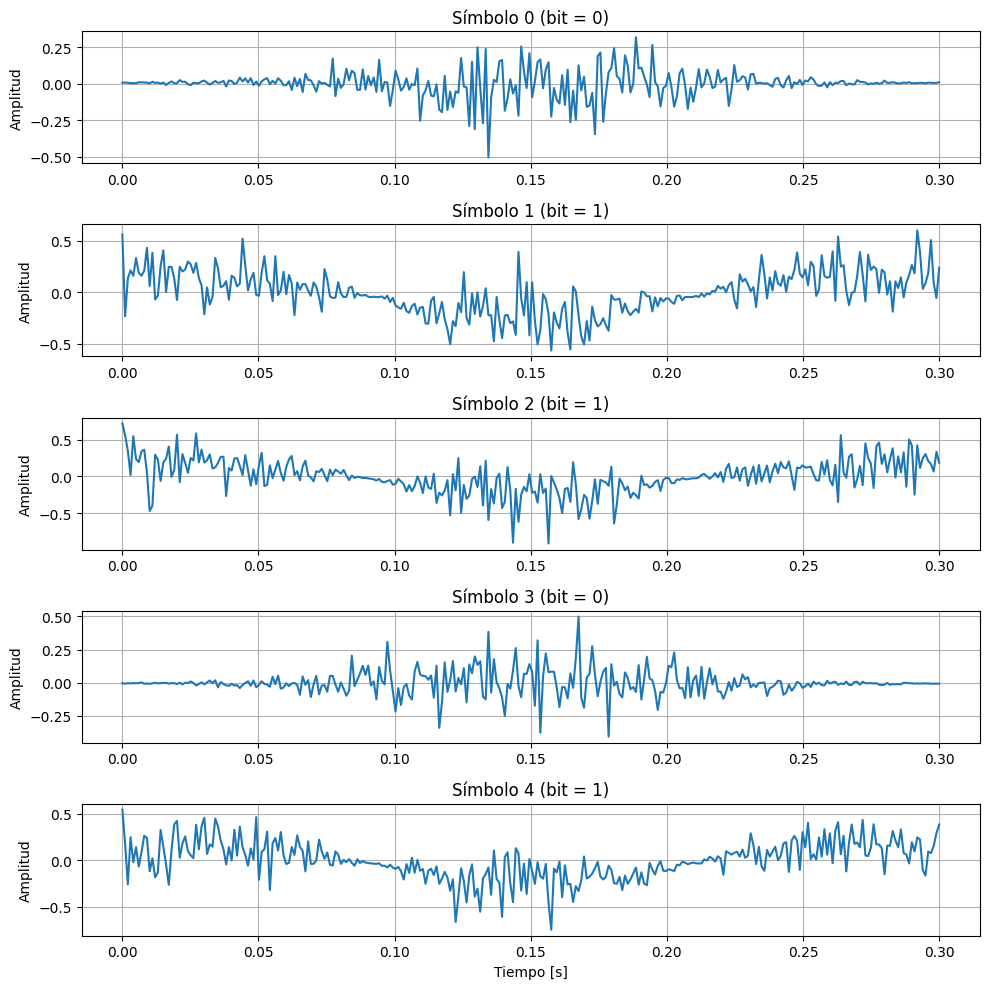

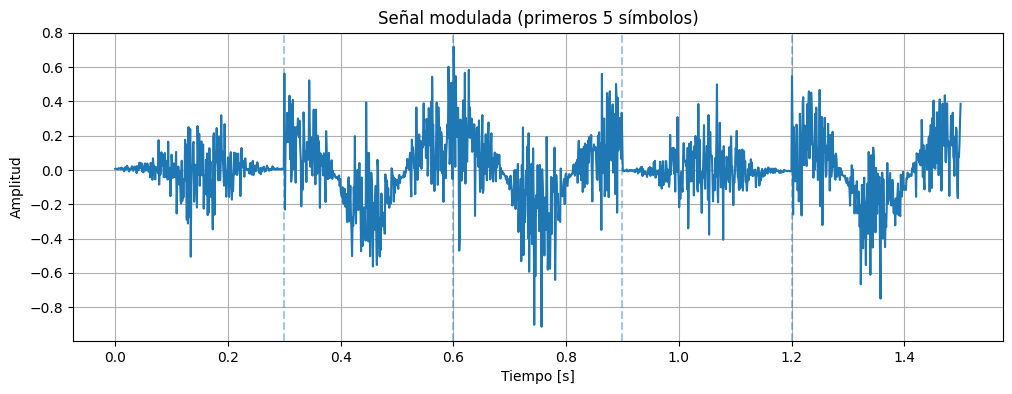

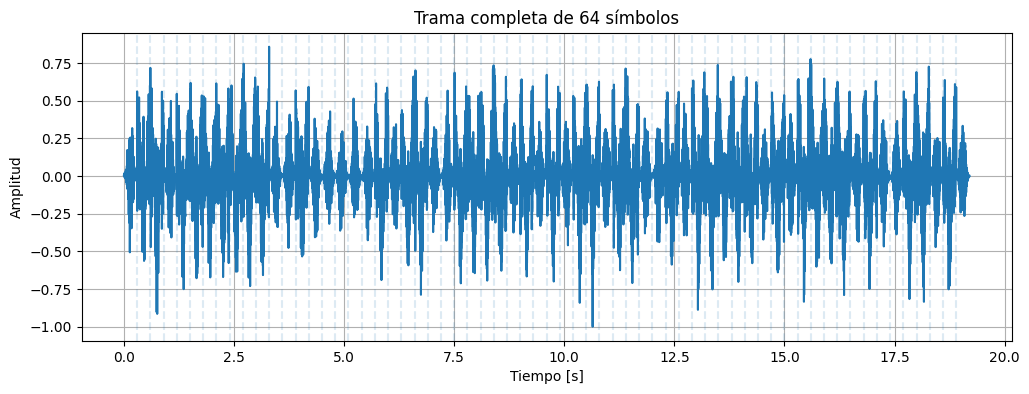

In [4]:
import torch
import math
import matplotlib.pyplot as plt

# ============ CONFIGURACIÓN ============
device = torch.device("cpu")
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

# Parámetros del sistema
Fs, T_symbol = 1000.0, 0.3
N = int(Fs * T_symbol)
D0, D1 = 0.4, 1.0
N_symbols = 64

# Secuencia de bits y eje temporal
bits = torch.randint(0, 2, (N_symbols,), device=device)
t_symbol = torch.linspace(0.0, T_symbol, N, device=device)

# ============ ENVOLVENTES ============
center, sigma_env = T_symbol / 2.0, T_symbol / 6.0
env0 = torch.exp(-0.5 * ((t_symbol - center) / sigma_env) ** 2)
env0 = env0 / env0.max()
env1 = 0.5 - env0

# Factores de escala
A0 = 1.0 / D1
A1 = 1.0 / (math.sqrt(2.0 * math.pi) * D1 * D0)

# ============ GENERACIÓN DE SÍMBOLOS ============
def generate_symbol(bit: int) -> torch.Tensor:
    if bit == 0:
        symbol = A0 * torch.randn(N, device=device) * D0 * env0
    else:
        symbol = (A1 - torch.randn(N, device=device) * D1) * env1
    return symbol - symbol.mean()  # Media cero

# Generar 64 símbolos y normalizar globalmente
symbols = torch.stack([generate_symbol(int(b.item())) for b in bits])
symbols /= symbols.abs().max()

# ============ SEÑALES ============
signal_full = symbols.reshape(-1)
t_full = torch.linspace(0.0, N_symbols * T_symbol, len(signal_full), device=device)

# Primeros 5 símbolos
n_show = 5
symbols_first5 = symbols[:n_show]
signal_first5 = symbols_first5.reshape(-1)
t_first5 = torch.linspace(0.0, n_show * T_symbol, len(signal_first5), device=device)

# ============ VISUALIZACIÓN ============
# 1. Símbolos individuales
fig, axes = plt.subplots(n_show, 1, figsize=(10, 10))
for i, ax in enumerate(axes):
    ax.plot(t_symbol.cpu(), symbols_first5[i].cpu())
    ax.set_title(f"Símbolo {i} (bit = {bits[i].item()})")
    ax.set_ylabel("Amplitud")
    ax.grid(True)
axes[-1].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

# 2. Señal modulada (5 símbolos)
plt.figure(figsize=(12, 4))
plt.plot(t_first5.cpu(), signal_first5.cpu())
for k in range(1, n_show):
    plt.axvline(k * T_symbol, linestyle="--", alpha=0.4)
plt.title("Señal modulada (primeros 5 símbolos)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# 3. Trama completa (64 símbolos)
plt.figure(figsize=(12, 4))
plt.plot(t_full.cpu(), signal_full.cpu())
for k in range(1, N_symbols):
    plt.axvline(k * T_symbol, linestyle="--", alpha=0.15)
plt.title("Trama completa de 64 símbolos")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


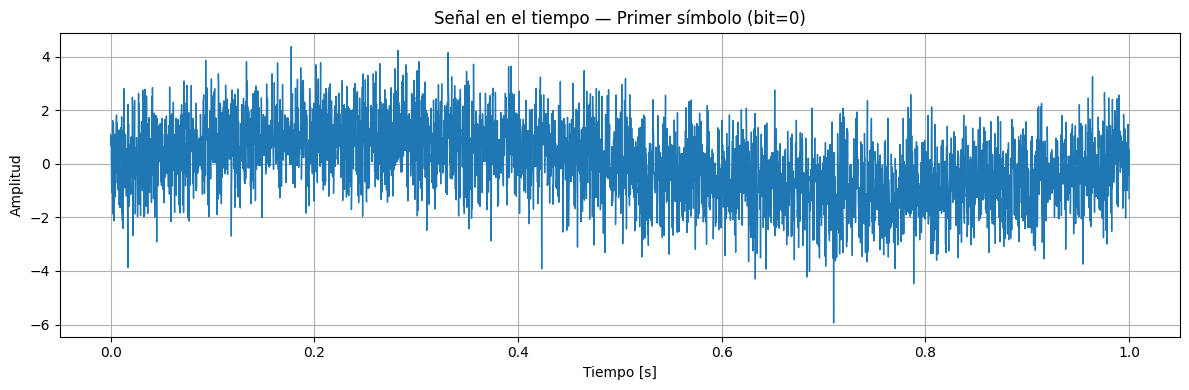

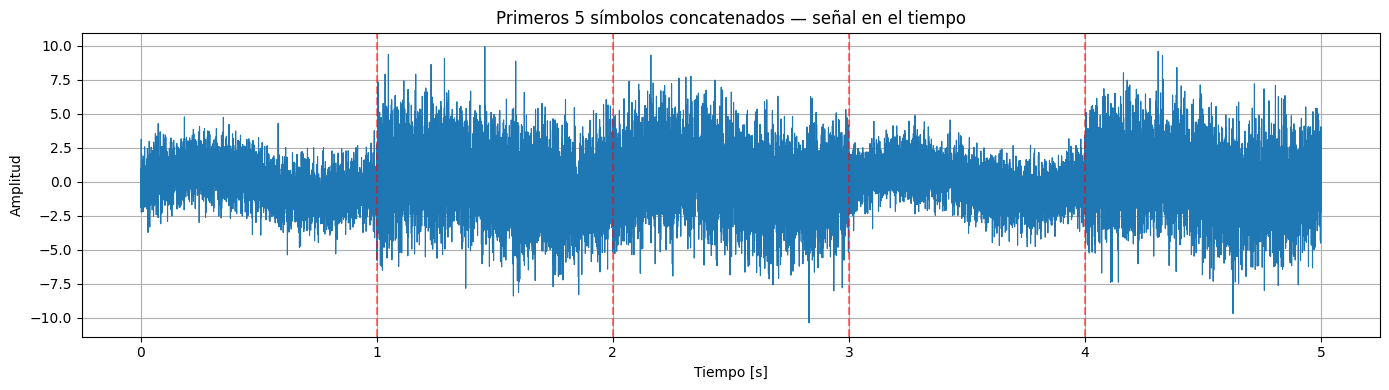

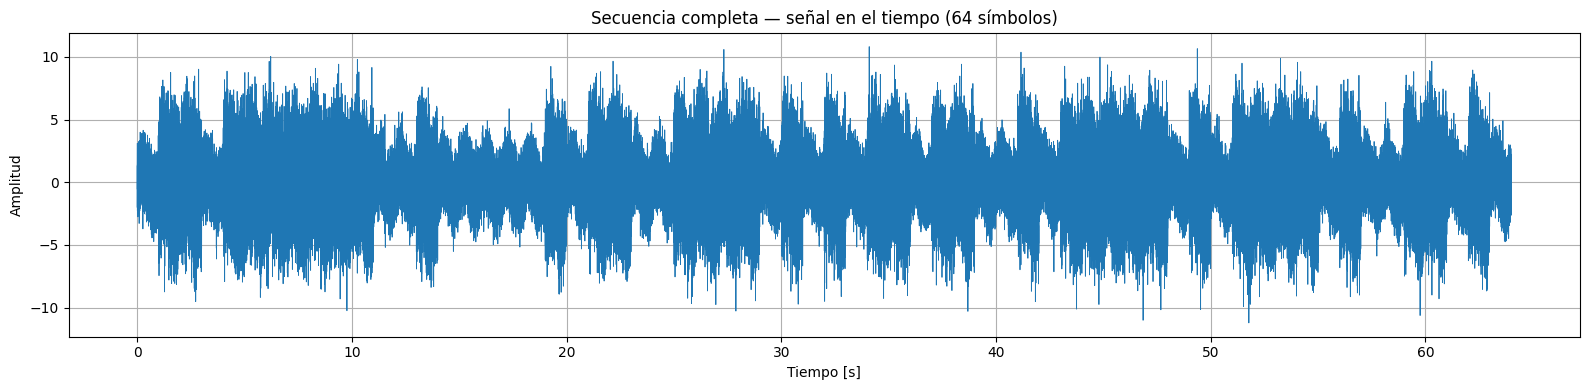

In [ ]:
# ============================================================
# EXTRAER UNA SEÑAL EN EL TIEMPO (primer símbolo)
# ============================================================

# Tomar los bits y generar solo un símbolo manualmente
b0 = bits_seq1[0].item()
sigma_t = sigma0_t if b0 == 0 else sigma1_t

# Generar la señal tal como en la función
x_n = sigma_t * torch.randn(N) + pilot
y_n = x_n + sigma_n * torch.randn(N)

# Vector de tiempo
t_np = np.linspace(0, 1, N)

# --- Graficar primer símbolo ---
plt.figure(figsize=(12,4))
plt.plot(t_np, y_n.numpy(), linewidth=1)
plt.title(f"Señal en el tiempo — Primer símbolo (bit={b0})")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Graficar los primeros 5 símbolos concatenados
# ============================================================

y_all = []

for i in range(5):
    b = bits_seq1[i].item()
    sigma_t = sigma0_t if b == 0 else sigma1_t
    x_i = sigma_t * torch.randn(N) + pilot
    y_i = x_i + sigma_n * torch.randn(N)
    y_all.append(y_i)

y_cat = torch.cat(y_all).numpy()
t_cat = np.linspace(0, 5, 5*N)

plt.figure(figsize=(14,4))
plt.plot(t_cat, y_cat, linewidth=0.8)
for k in range(1,5):
    plt.axvline(k, color='red', linestyle='--', alpha=0.5)
plt.title("Primeros 5 símbolos concatenados — señal en el tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Graficar la secuencia completa (64 símbolos)
# ============================================================

y_full = []

for i in range(num_symbols):
    b = bits_seq1[i].item()
    sigma_t = sigma0_t if b == 0 else sigma1_t
    x_i = sigma_t * torch.randn(N) + pilot
    y_i = x_i + sigma_n * torch.randn(N)
    y_full.append(y_i)

y_full = torch.cat(y_full).numpy()
t_full = np.linspace(0, num_symbols, num_symbols*N)

plt.figure(figsize=(16,4))
plt.plot(t_full, y_full, linewidth=0.6)
plt.title("Secuencia completa — señal en el tiempo (64 símbolos)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()


## Canal de Transmisión y Modelado del Ruido

La señal recibida en el canal está dada por:

$$
y(t) = x(d_i, t) + \eta(t)
$$

Donde:

* $x(d_i,t)$ es la señal transmitida, con $i \in \{0,1\}$.
* $\eta(t)$ es ruido aditivo blanco gaussiano (AWGN), con distribución:

$$
\eta(t) \sim \mathcal{N}(0, \sigma_\eta^2)
$$

Adicionalmente, el canal incluye un término de desplazamiento (offset) definido como:

$$
G = K \cdot \min\{D_0, D_1\}
$$

Donde:

* $K \approx 0.3$ es un factor de escala.
* $D_0$ y $D_1$ son parámetros asociados a la dispersión de las dos distribuciones de los símbolos.

Por lo tanto, la señal final recibida incorpora tanto el ruido gaussiano como este componente basado en la mínima dispersión entre los símbolos.

La forma final del canal se escribe como:

$$
y(t) = x(d_i,t) + \eta(t) + K \cdot \min\{D_0, D_1\}
$$

Este modelo permite estudiar cómo la presencia de ruido y el desplazamiento afectan la forma de onda recibida.

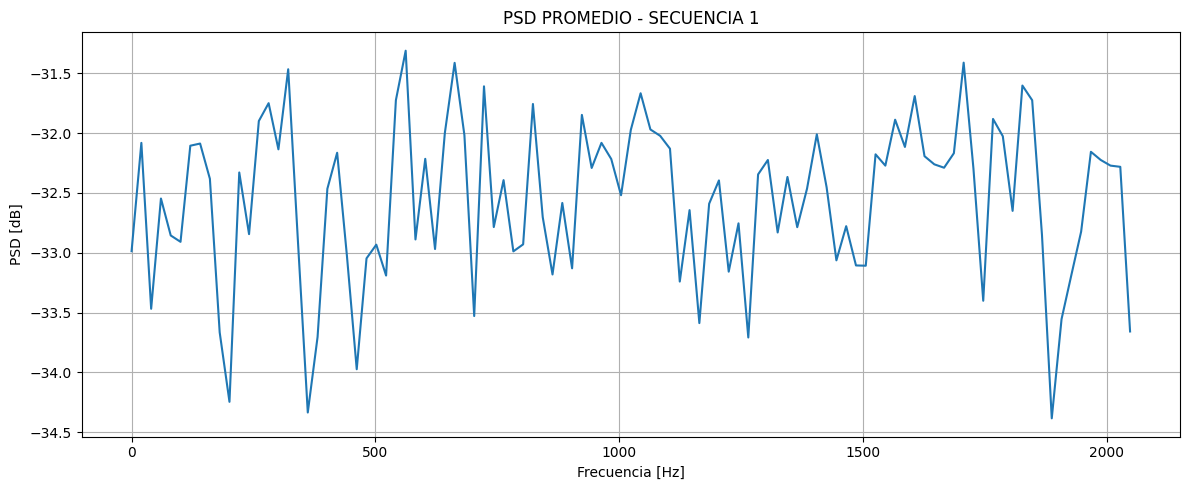

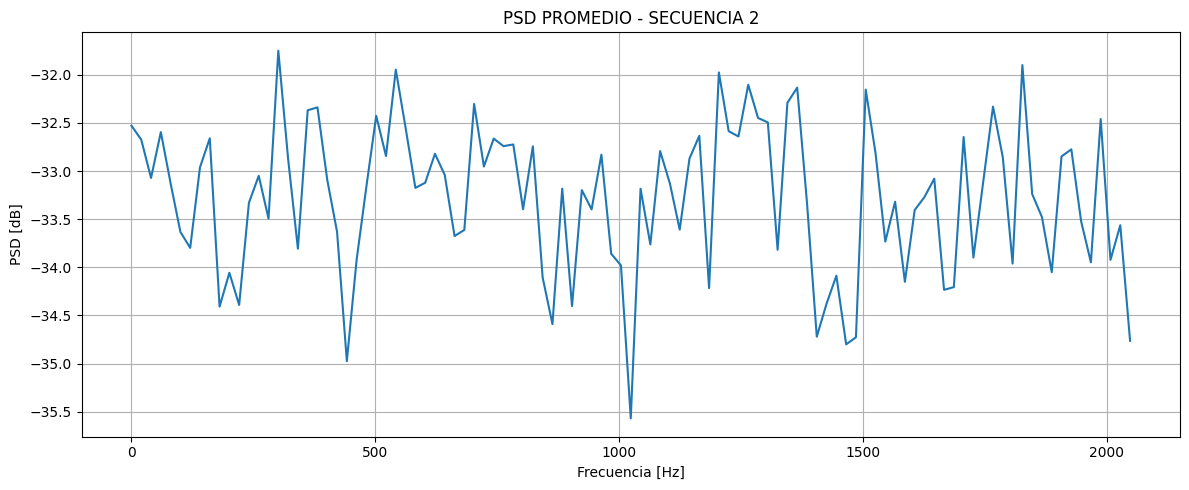

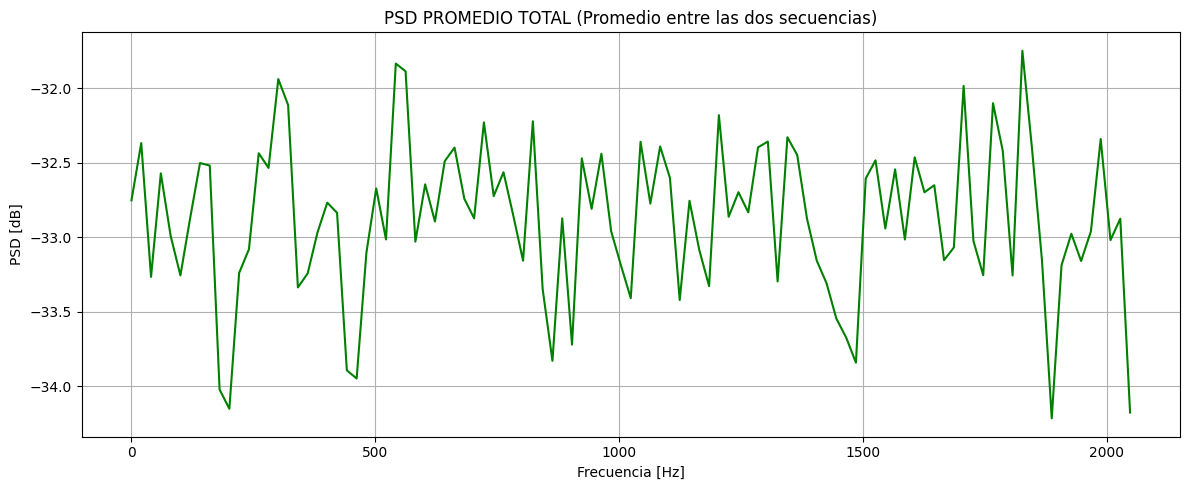

Bits secuencia 1: [1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1]
Bits secuencia 2: [0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1]


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================
torch.manual_seed(10)
np.random.seed(10)

Fs = 4096
T_symbol = 0.05
N = int(Fs * T_symbol)

# Dispersión de las dos clases
D0 = 1.2
D1 = 2.4

# Ruido de canal
k = 0.25
sigma_eta = k * min(D0, D1)

# ============================================================
# PERFILES DE DISPERSIÓN
# ============================================================
t = torch.linspace(-3.0, 3.0, N)

def gauss_env(t, sigma):
    g = torch.exp(-t**2 / (2 * sigma**2))
    return g / g.max()   # normalizar altura máx = 1

sigma_profile_0 = D0 * gauss_env(t, D0)
sigma_profile_1 = D1 * gauss_env(t, D1)


# ============================================================
# FUNCION PERIODOGRAMA
# ============================================================
def periodogram(signal, Fs):
    """Periodograma en PyTorch."""
    N = signal.numel()
    X = torch.fft.rfft(signal)
    Pxx = (1/(Fs*N)) * torch.abs(X)**2
    freqs = torch.linspace(0, Fs/2, Pxx.numel())
    return freqs, Pxx


# ============================================================
# GENERA UNA SECUENCIA Y SU ESPECTRO PROMEDIO
# ============================================================
def process_sequence(name, bits):
    x_segments = []
    y_segments = []
    PSD_list = []

    for i, b in enumerate(bits):
        sigma_t = sigma_profile_0 if b == 0 else sigma_profile_1

        x_t = sigma_t * torch.randn(N)
        y_t = x_t + sigma_eta * torch.randn(N)

        # Guardar
        x_segments.append(x_t)
        y_segments.append(y_t)

        # PSD por símbolo
        _, Pyy = periodogram(y_t, Fs)
        PSD_list.append(Pyy)

    PSD_tensor = torch.stack(PSD_list)           # shape (64, F)
    PSD_avg = PSD_tensor.mean(dim=0)             # PSD promedio

    return PSD_avg


# ============================================================
# SECUENCIAS DE 64 BITS
# ============================================================
bits_seq1 = torch.randint(0, 2, (64,))
bits_seq2 = torch.randint(0, 2, (64,))

# ============================================================
# PROCESAMIENTO: PSD PROMEDIO
# ============================================================
PSD_avg_seq1 = process_sequence("SEQ1", bits_seq1)
PSD_avg_seq2 = process_sequence("SEQ2", bits_seq2)

# PSD total (sobre 64 símbolos)
PSD_total_avg = (PSD_avg_seq1 + PSD_avg_seq2) / 2

# ============================================================
# GRAFICACIÓN
# ============================================================
# Frecuencias
f = torch.linspace(0, Fs/2, PSD_avg_seq1.numel())

plt.figure(figsize=(12,5))
plt.plot(f, 10*torch.log10(PSD_avg_seq1), label="PSD promedio secuencia 1")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("PSD PROMEDIO - SECUENCIA 1")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(f, 10*torch.log10(PSD_avg_seq2), label="PSD promedio secuencia 2")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("PSD PROMEDIO - SECUENCIA 2")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(f, 10*torch.log10(PSD_total_avg), label="PSD promedio TOTAL", color="green")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("PSD PROMEDIO TOTAL (Promedio entre las dos secuencias)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Bits secuencia 1:", bits_seq1.tolist())
print("Bits secuencia 2:", bits_seq2.tolist())


#**Espectro normalizado**

/tmp/ipython-input-1759213676.py:73: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  psd0_db = 10 * np.log10(psd0_pos.cpu() + 1e-15)
/tmp/ipython-input-1759213676.py:74: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  psd1_db = 10 * np.log10(psd1_pos.cpu() + 1e-15)


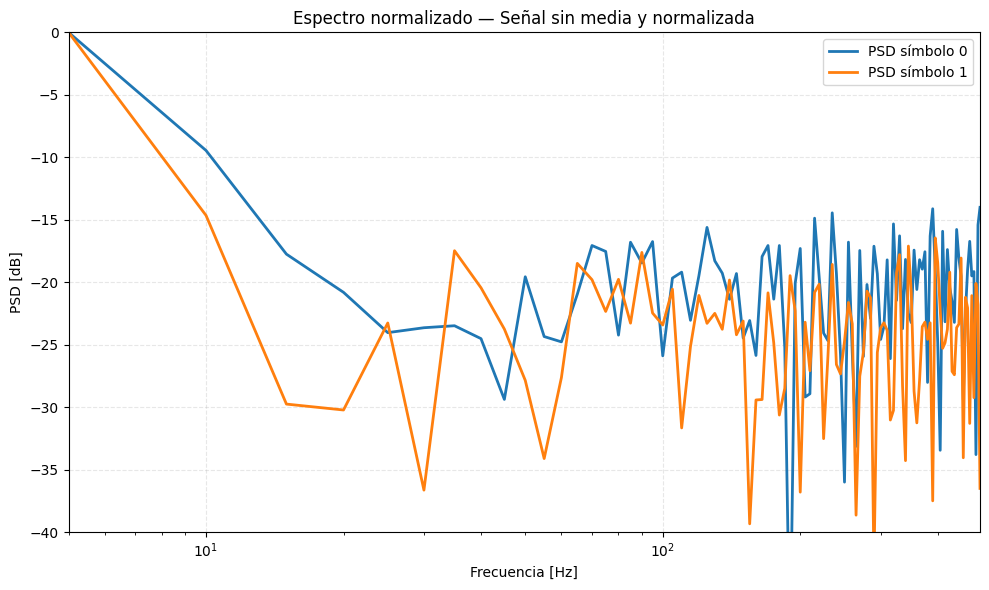

Periodo de muestreo Ts = 1.00 ms (base de tiempo correcta)
Media símbolo 0: 0.000000 (debería ser ~0)
Media símbolo 1: 0.000000 (debería ser ~0)
Std símbolo 0: 1.000000 (debería ser ~1)
Std símbolo 1: 1.000000 (debería ser ~1)


In [9]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# ================= CONFIGURACIÓN =================
device = torch.device("cpu")
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

Fs = 1000.0           # Frecuencia de muestreo → Ts = 1 ms
Ts = 1/Fs             # Periodo de muestreo (1 ms)
T_symbol = 0.2        # Duración de símbolo
N = int(Fs * T_symbol)

# ========== TIEMPO — INICIA EXACTAMENTE EN 0 ==========
t = torch.arange(0, N, device=device) * Ts

# Envolventes
center = T_symbol / 2
sigma_env = T_symbol / 6

env0 = torch.exp(-0.5 * ((t - center) / sigma_env)**2)
env0 /= env0.max()

env1 = 1.0 - env0

# Factores de amplitud
A0 = 1.0
A1 = 1.5

# Símbolos
symbol0 = A0 * env0
symbol1 = A1 * env1

# Ruido
sigma_noise = 0.4
symbol0_noisy = symbol0 + sigma_noise * torch.randn_like(symbol0)
symbol1_noisy = symbol1 + sigma_noise * torch.randn_like(symbol1)

# ========== QUITAR MEDIA Y NORMALIZAR ==========
# Quitar la media (componente DC)
symbol0_noisy = symbol0_noisy - symbol0_noisy.mean()
symbol1_noisy = symbol1_noisy - symbol1_noisy.mean()

# Normalizar (dividir por desviación estándar)
symbol0_noisy = symbol0_noisy / symbol0_noisy.std()
symbol1_noisy = symbol1_noisy / symbol1_noisy.std()

# ================= PSD =================
def psd_periodogram(x, fs):
    Nloc = x.shape[-1]
    Xf = torch.fft.fft(x)
    psd = (Xf.conj() * Xf).real / (Nloc * fs)
    freqs = torch.fft.fftfreq(Nloc, 1/fs)
    mask = freqs >= 0
    return freqs[mask], psd[mask]

freqs0, psd0 = psd_periodogram(symbol0_noisy, Fs)
freqs1, psd1 = psd_periodogram(symbol1_noisy, Fs)

# ======== FILTRAR SOLO FRECUENCIAS POSITIVAS ========
mask_pos0 = freqs0 > 0
mask_pos1 = freqs1 > 0

freqs0_pos = freqs0[mask_pos0]
freqs1_pos = freqs1[mask_pos1]

psd0_pos = psd0[mask_pos0]
psd1_pos = psd1[mask_pos1]

# ========== NORMALIZACIÓN A 0 dB ==========
psd0_db = 10 * np.log10(psd0_pos.cpu() + 1e-15)
psd1_db = 10 * np.log10(psd1_pos.cpu() + 1e-15)

psd0_db -= psd0_db.max()
psd1_db -= psd1_db.max()

# ================= GRAFICADO =================
plt.figure(figsize=(10,6))

plt.plot(freqs0_pos.cpu(), psd0_db, label="PSD símbolo 0", linewidth=2)
plt.plot(freqs1_pos.cpu(), psd1_db, label="PSD símbolo 1", linewidth=2)

plt.xscale("log")
plt.ylim([-40, 0])
plt.xlim([freqs0_pos.min().item(), freqs0_pos.max().item()])

plt.grid(True, linestyle="--", alpha=0.3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Espectro normalizado — Señal sin media y normalizada")

plt.legend()
plt.tight_layout()
plt.show()

print(f"Periodo de muestreo Ts = {Ts*1000:.2f} ms (base de tiempo correcta)")
print(f"Media símbolo 0: {symbol0_noisy.mean():.6f} (debería ser ~0)")
print(f"Media símbolo 1: {symbol1_noisy.mean():.6f} (debería ser ~0)")
print(f"Std símbolo 0: {symbol0_noisy.std():.6f} (debería ser ~1)")
print(f"Std símbolo 1: {symbol1_noisy.std():.6f} (debería ser ~1)")

## Canal Aplicado a una Secuencia de 64 Símbolos

Sea el vector de datos:

$$
\mathbf{d} \in \{0,1\}^{64}
$$

Donde cada elemento del vector corresponde a un símbolo binario, tal que:

$$
d_i \in \{0,1\}, \quad i=1, \dots, 64
$$

Para cada símbolo $d_i$, la señal transmitida está dada por $x_i(t) = x(d_i, t)$. El canal afecta a cada forma de onda individual mediante la ecuación:

$$
y_i(t) = x_i(t) + \eta(t) + K \cdot \min\{D_0, D_1\}
$$

Donde:

* $\eta(t) \sim \mathcal{N}(0, \sigma_\eta^2)$ representa el componente de ruido.
* $K \approx 0.3$ es el factor de escala del término constante.

> **Nota de visualización:** En la gráfica siguiente solo se muestran las señales recibidas correspondientes a los **primeros 5 símbolos** de la secuencia total de 64.

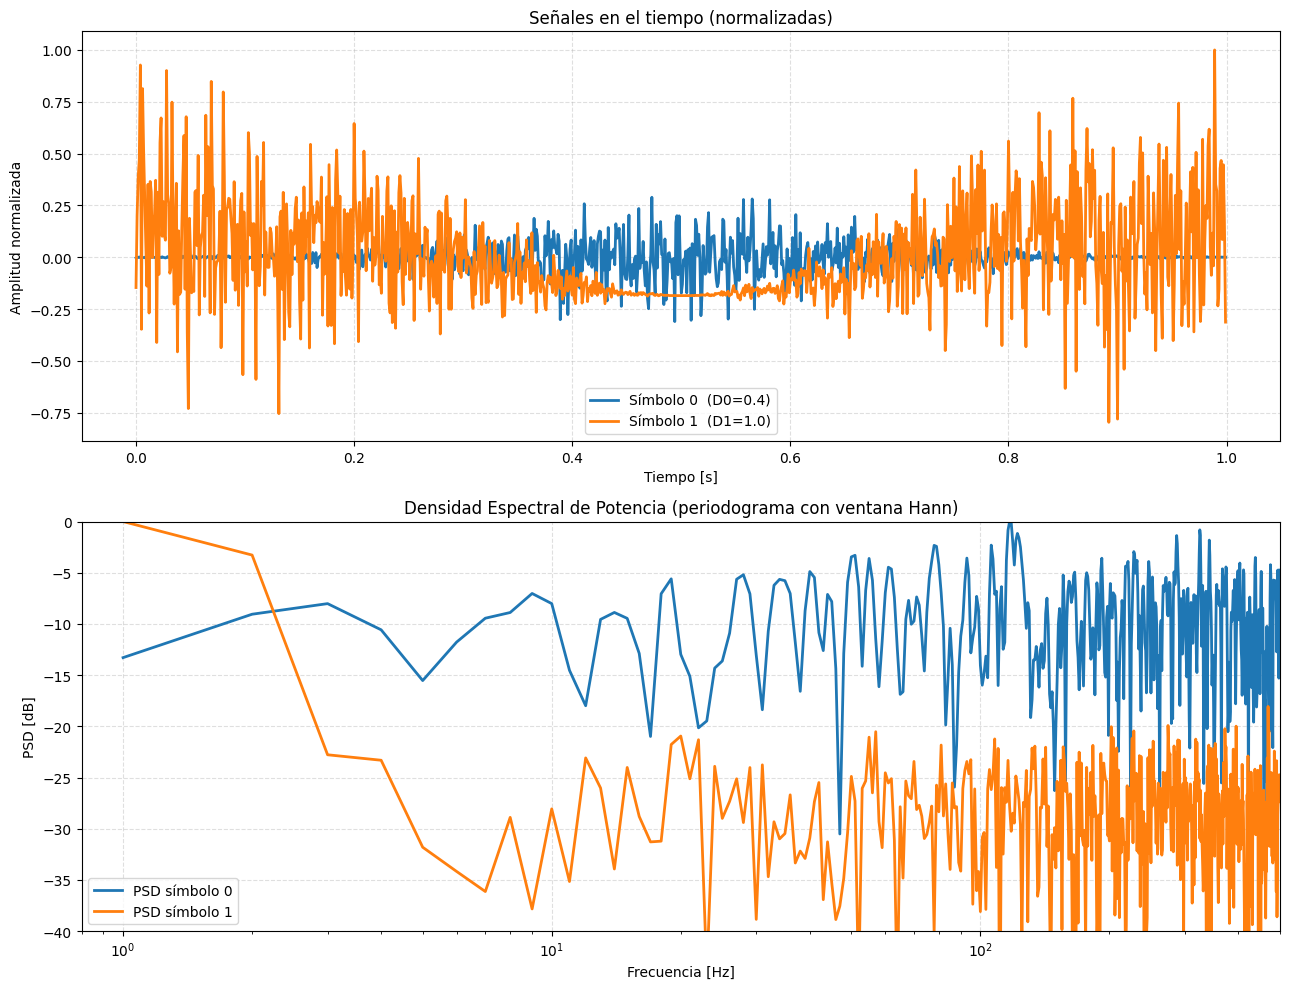

Fs = 1000.0 Hz — Ts = 1.00 ms — N = 1000 muestras
D0 = 0.4, D1 = 1.0
Media símbolo 0: 0.000000
Media símbolo 1: -0.000000
Max abs símbolo 0: 0.309907
Max abs símbolo 1: 1.000000


In [10]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# ===================== CONFIGURACIÓN =====================
device = torch.device("cpu")
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

Fs = 1000.0           # Frecuencia de muestreo
Ts = 1/Fs
T_symbol = 1.0
N = int(Fs * T_symbol)

# Parámetros del modelo
D0 = 0.4
D1 = 1.0

# ===================== TIEMPO =====================
t = torch.arange(0, N, device=device) * Ts

center = T_symbol / 2
sigma_env = T_symbol / 6

# Envolventes normalizadas
env0 = torch.exp(-0.5 * ((t - center) / sigma_env)**2)
env0 /= env0.max()
env1 = 1.0 - env0

# Factores de amplitud
A0 = 1.0 / D1
A1 = 1.0 / (math.sqrt(2.0 * math.pi) * D1 * D0)

# ===================== GENERACIÓN =====================
def generate_symbol(bit: int) -> torch.Tensor:
    if bit == 0:
        symbol = A0 * torch.randn(N, device=device) * D0 * env0
    else:
        symbol = (A1 - torch.randn(N, device=device) * D1) * env1
    return symbol - symbol.mean()  # Sin DC

symbol0 = generate_symbol(0)
symbol1 = generate_symbol(1)

# Normalización global
max_abs = max(symbol0.abs().max(), symbol1.abs().max())
symbol0 /= max_abs
symbol1 /= max_abs

# ===================== PSD (MEJORADA con ventana Hann) =====================

def psd_periodogram(x, fs):
    Nloc = len(x)

    # Ventana Hann para suprimir leakage
    window = torch.hann_window(Nloc, periodic=True, device=device)
    xw = x * window

    Xf = torch.fft.fft(xw)
    psd = (Xf.conj() * Xf).real / (window.pow(2).sum() * fs)

    freqs = torch.fft.fftfreq(Nloc, 1/fs)
    mask = freqs > 0
    return freqs[mask], psd[mask]

freqs0, psd0 = psd_periodogram(symbol0, Fs)
freqs1, psd1 = psd_periodogram(symbol1, Fs)

# Evitar log(0)
psd0_db = 10 * torch.log10(psd0 + 1e-15)
psd1_db = 10 * torch.log10(psd1 + 1e-15)

# Normalizar a 0 dB
psd0_db -= psd0_db.max()
psd1_db -= psd1_db.max()

# ===================== GRAFICADO =====================
plt.figure(figsize=(13, 10))

# ----------- Señales en el tiempo -----------
plt.subplot(2, 1, 1)
plt.plot(t.cpu(), symbol0.cpu(), label=f"Símbolo 0  (D0={D0})", linewidth=2)
plt.plot(t.cpu(), symbol1.cpu(), label=f"Símbolo 1  (D1={D1})", linewidth=2)

plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud normalizada")
plt.title("Señales en el tiempo (normalizadas)")
plt.legend()

# ----------- PSD -----------
plt.subplot(2, 1, 2)
plt.plot(freqs0.cpu(), psd0_db.cpu(), label="PSD símbolo 0", linewidth=2)
plt.plot(freqs1.cpu(), psd1_db.cpu(), label="PSD símbolo 1", linewidth=2)

plt.xscale("log")
plt.ylim([-40, 0])
plt.xlim([0.8, Fs/2])

plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Densidad Espectral de Potencia (periodograma con ventana Hann)")
plt.legend()

plt.tight_layout()
plt.show()

# ===================== INFORMACIÓN =====================
print(f"Fs = {Fs} Hz — Ts = {Ts*1000:.2f} ms — N = {N} muestras")
print(f"D0 = {D0}, D1 = {D1}")
print(f"Media símbolo 0: {symbol0.mean():.6f}")
print(f"Media símbolo 1: {symbol1.mean():.6f}")
print(f"Max abs símbolo 0: {symbol0.abs().max():.6f}")
print(f"Max abs símbolo 1: {symbol1.abs().max():.6f}")


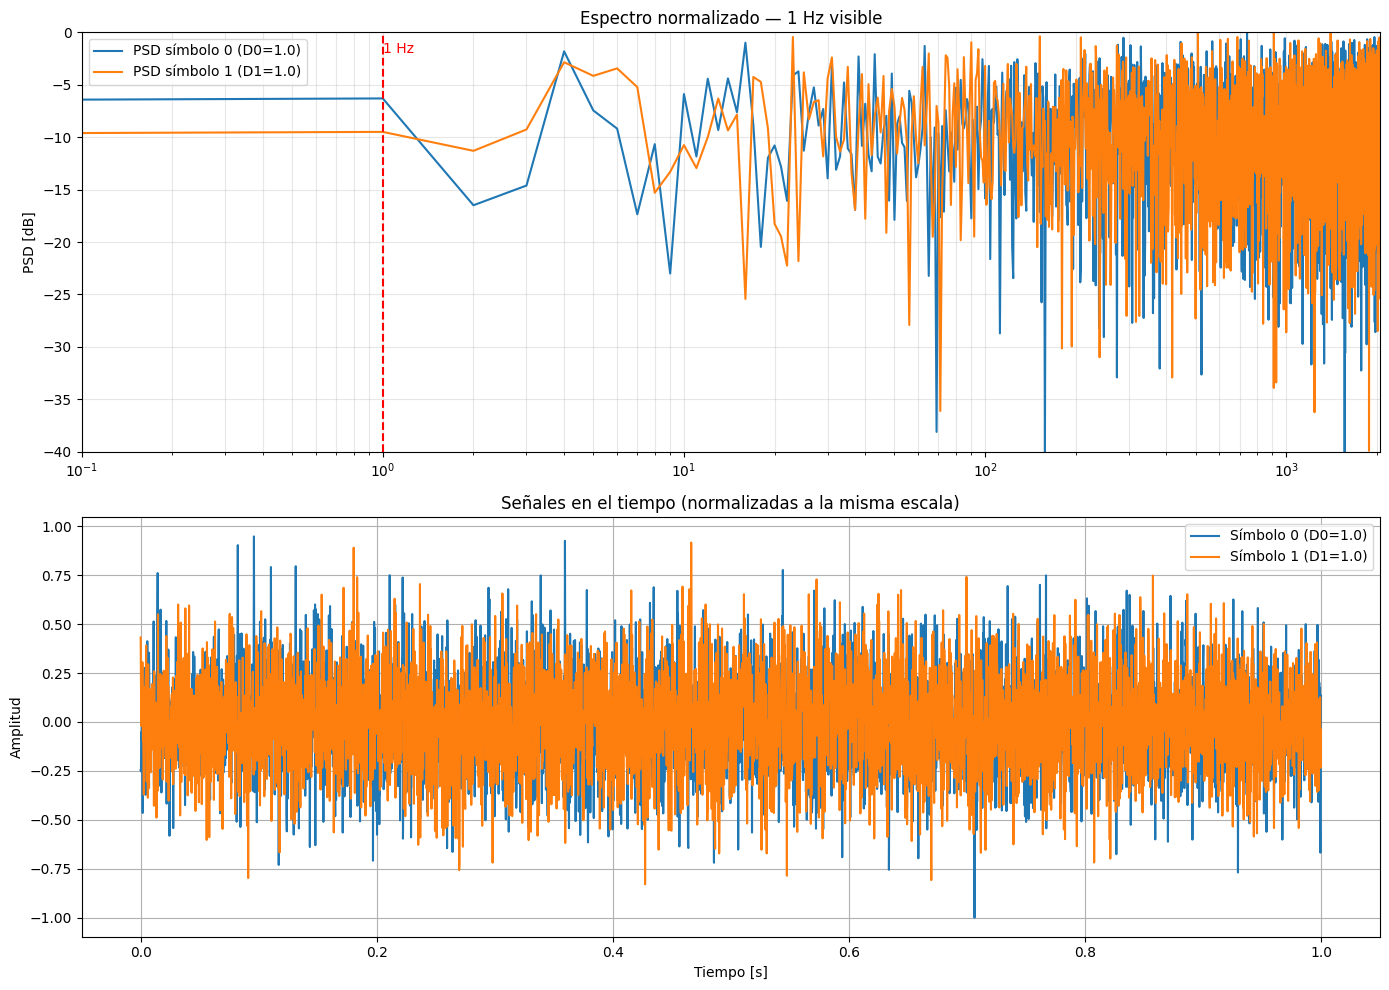

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN
# ============================================================
torch.manual_seed(0)
np.random.seed(0)

Fs = 4096          # Frecuencia de muestreo
T_symbol = 1.0     # 1 segundo por símbolo  → base de tiempo bien calibrada
N = int(Fs * T_symbol)

D0 = 1.0
D1 = 1.0           # Condición pedida: D0 = D1

t = torch.linspace(0, T_symbol, N)

# ============================================================
# ENVOLVENTE GAUSSIANA σ(t)
# ============================================================
def gauss_env(t, sigma):
    g = torch.exp(-(t - 0.5)**2 / (2*sigma**2))
    return g / g.max()

sigma0_t = D0 * gauss_env(t, D0)
sigma1_t = D1 * gauss_env(t, D1)

# ============================================================
# GENERAR SEÑALES EN EL TIEMPO
# ============================================================
# Ruido Gaussiano
w0 = torch.randn(N)
w1 = torch.randn(N)

x0 = sigma0_t * w0
x1 = sigma1_t * w1

# Remover DC (importantísimo para PSD correcta)
x0 = x0 - x0.mean()
x1 = x1 - x1.mean()

# Normalizar a misma escala
scale = max(x0.abs().max(), x1.abs().max())
x0n = x0 / scale
x1n = x1 / scale

# ============================================================
# PERIODOGRAMA NORMALIZADO EN dB
# ============================================================
def periodogram_dB(x, Fs):
    N = x.numel()
    Xf = torch.fft.rfft(x)
    PSD = (1/(Fs*N)) * torch.abs(Xf)**2
    PSD = PSD / PSD.max()            # Normalización para que el pico sea 0 dB
    PSD_dB = 10 * torch.log10(PSD + 1e-12)
    freqs = torch.linspace(0, Fs/2, PSD.numel())
    return freqs, PSD_dB

f0, PSD0 = periodogram_dB(x0n, Fs)
f1, PSD1 = periodogram_dB(x1n, Fs)

# ============================================================
# GRAFICAR — PSD
# ============================================================
plt.figure(figsize=(14,10))

plt.subplot(2,1,1)
plt.plot(f0, PSD0, label="PSD símbolo 0 (D0=1.0)")
plt.plot(f1, PSD1, label="PSD símbolo 1 (D1=1.0)")

plt.xscale("log")
plt.ylim([-40, 0])
plt.xlim([1e-1, Fs/2])

# Línea vertical en 1 Hz
plt.axvline(1, color="red", linestyle="--")
plt.text(1, -2, "1 Hz", color="red", fontsize=10)

plt.grid(True, which="both", alpha=0.3)
plt.ylabel("PSD [dB]")
plt.title("Espectro normalizado — 1 Hz visible")
plt.legend()

# ============================================================
# GRAFICAR — SEÑAL EN EL TIEMPO
# ============================================================
plt.subplot(2,1,2)
plt.plot(t, x0n, label="Símbolo 0 (D0=1.0)")
plt.plot(t, x1n, label="Símbolo 1 (D1=1.0)")

plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señales en el tiempo (normalizadas a la misma escala)")
plt.legend()

plt.tight_layout()
plt.show()


#**Función de Autocorrelación**

/tmp/ipython-input-2556820519.py:78: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  psd0_db = 10 * np.log10(psd0.cpu() + 1e-15)
/tmp/ipython-input-2556820519.py:79: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  psd1_db = 10 * np.log10(psd1.cpu() + 1e-15)


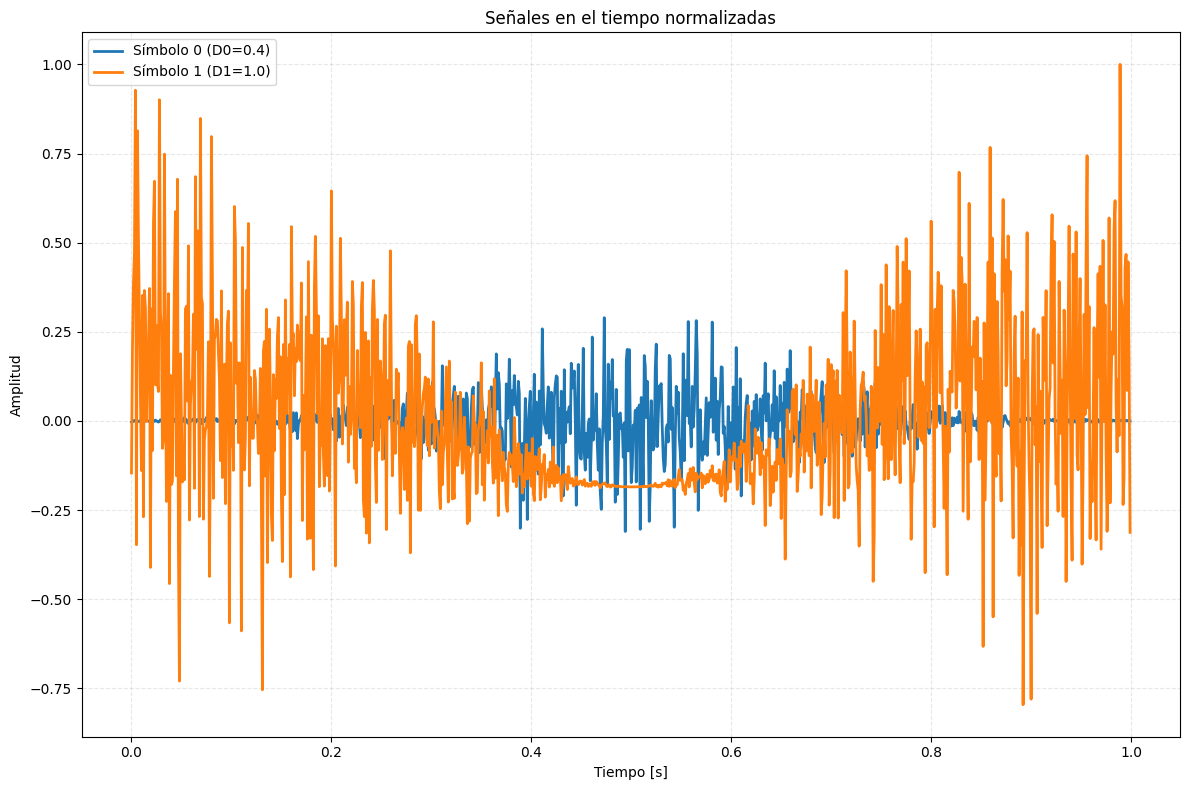

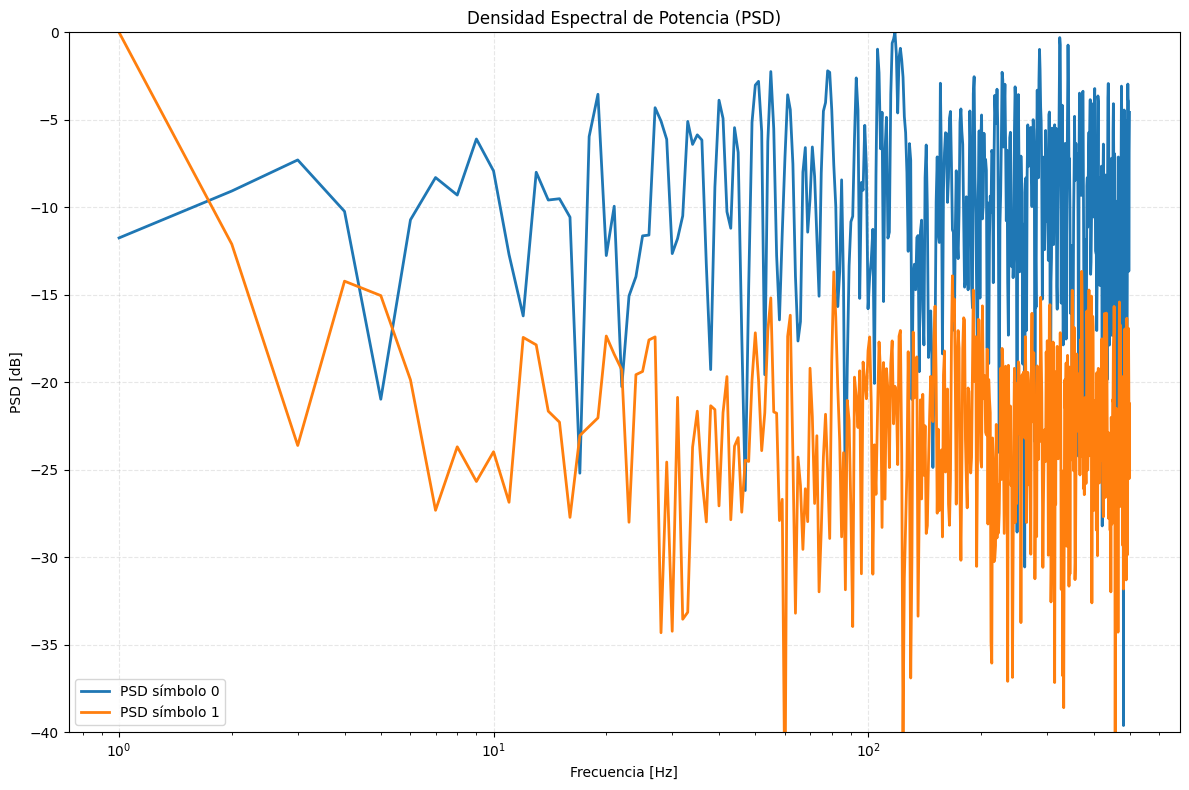

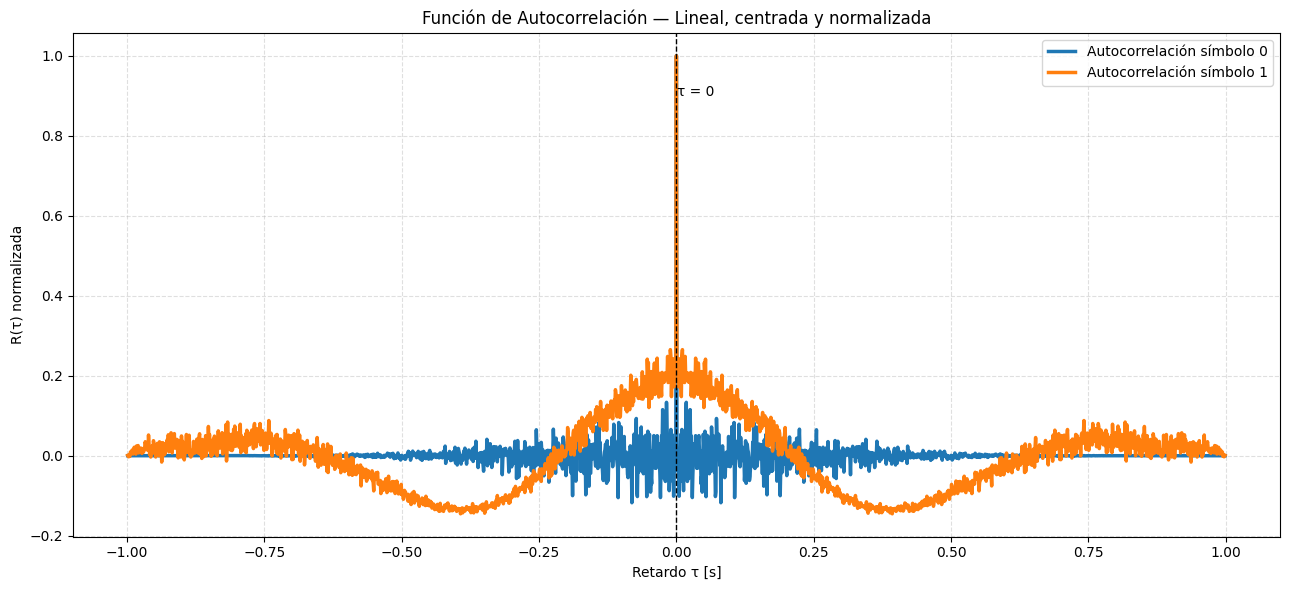

N = 1000 muestras — Fs = 1000.0 Hz — Ts = 1.00 ms
Media símbolo 0: 0.000000
Media símbolo 1: -0.000000
Max abs símbolos: 3.285877


In [12]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# ==========================================================
#                     CONFIGURACIÓN
# ==========================================================
device = torch.device("cpu")
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

Fs = 1000.0          # Frecuencia de muestreo (Hz)
Ts = 1 / Fs          # Periodo
T_symbol = 1.0       # Duración del símbolo (1 s)
N = int(Fs * T_symbol)

# Parámetros D0 y D1
D0 = 0.4
D1 = 1.0

# Tiempo
t = torch.arange(0, N, device=device) * Ts

# ==========================================================
#                   ENVOLVENTES
# ==========================================================
center = T_symbol / 2
sigma_env = T_symbol / 6

env0 = torch.exp(-0.5 * ((t - center) / sigma_env) ** 2)
env0 /= env0.max()

env1 = 1.0 - env0

A0 = 1.0 / D1
A1 = 1.0 / (math.sqrt(2.0 * math.pi) * D1 * D0)

# ==========================================================
#            GENERACIÓN DE SÍMBOLOS
# ==========================================================
def generate_symbol(bit: int) -> torch.Tensor:
    if bit == 0:
        symbol = A0 * torch.randn(N, device=device) * D0 * env0
    else:
        symbol = (A1 - torch.randn(N, device=device) * D1) * env1
    return symbol


symbol0 = generate_symbol(0)
symbol1 = generate_symbol(1)

# ==========================================================
#     QUITAR MEDIA Y NORMALIZAR EN ESCALA COMÚN
# ==========================================================
symbol0 = symbol0 - symbol0.mean()
symbol1 = symbol1 - symbol1.mean()

max_abs = max(symbol0.abs().max(), symbol1.abs().max())
symbol0 /= max_abs
symbol1 /= max_abs

# ==========================================================
#                   PERIODOGRAMA
# ==========================================================
def psd_periodogram(x, fs):
    Nloc = len(x)
    X = torch.fft.fft(x)
    psd = (X.conj() * X).real / (Nloc * fs)
    freqs = torch.fft.fftfreq(Nloc, 1/fs)

    mask = freqs > 0
    return freqs[mask], psd[mask]

freqs0, psd0 = psd_periodogram(symbol0, Fs)
freqs1, psd1 = psd_periodogram(symbol1, Fs)

psd0_db = 10 * np.log10(psd0.cpu() + 1e-15)
psd1_db = 10 * np.log10(psd1.cpu() + 1e-15)

psd0_db -= psd0_db.max()
psd1_db -= psd1_db.max()

# ==========================================================
#           AUTOCORRELACIÓN PERFECTA
# ==========================================================
def autocorrelation_perfect(x: torch.Tensor, fs: float, normalized=True):
    x = x - x.mean()
    N = len(x)
    Npad = 2 * N

    Xf = torch.fft.fft(x, n=Npad)
    Rf = Xf * torch.conj(Xf)
    r = torch.fft.ifft(Rf).real

    r = torch.cat((r[-(N-1):], r[:N]))

    if normalized:
        r = r / r.max()

    lags = torch.arange(-(N-1), N, device=x.device)
    return lags, r

lags0, R0 = autocorrelation_perfect(symbol0, Fs)
lags1, R1 = autocorrelation_perfect(symbol1, Fs)

tau0 = lags0 / Fs
tau1 = lags1 / Fs

# ==========================================================
#                       GRAFICADO
# ==========================================================

plt.figure(figsize=(12, 8))
plt.plot(t.cpu(), symbol0.cpu(), label=f"Símbolo 0 (D0={D0})", linewidth=2)
plt.plot(t.cpu(), symbol1.cpu(), label=f"Símbolo 1 (D1={D1})", linewidth=2)
plt.grid(True, linestyle="--", alpha=0.3)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señales en el tiempo normalizadas")
plt.legend()
plt.tight_layout()
plt.show()

# ---- PSD ----
plt.figure(figsize=(12, 8))
plt.plot(freqs0.cpu(), psd0_db, label="PSD símbolo 0", linewidth=2)
plt.plot(freqs1.cpu(), psd1_db, label="PSD símbolo 1", linewidth=2)

plt.xscale("log")
plt.ylim([-40, 0])
plt.grid(True, linestyle="--", alpha=0.3)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Densidad Espectral de Potencia (PSD)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- FUNCION DE AUTOCORRELACIÓN ----
plt.figure(figsize=(13, 6))
plt.plot(tau0.cpu(), R0.cpu(), label="Autocorrelación símbolo 0", linewidth=2.5)
plt.plot(tau1.cpu(), R1.cpu(), label="Autocorrelación símbolo 1", linewidth=2.5)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.text(0.002, 0.9, "τ = 0", color="black")

plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("Retardo τ [s]")
plt.ylabel("R(τ) normalizada")
plt.title("Función de Autocorrelación — Lineal, centrada y normalizada")
plt.legend()
plt.tight_layout()
plt.show()

# ---- INFO ----
print(f"N = {N} muestras — Fs = {Fs} Hz — Ts = {Ts*1000:.2f} ms")
print(f"Media símbolo 0: {symbol0.mean():.6f}")
print(f"Media símbolo 1: {symbol1.mean():.6f}")
print(f"Max abs símbolos: {max_abs:.6f}")


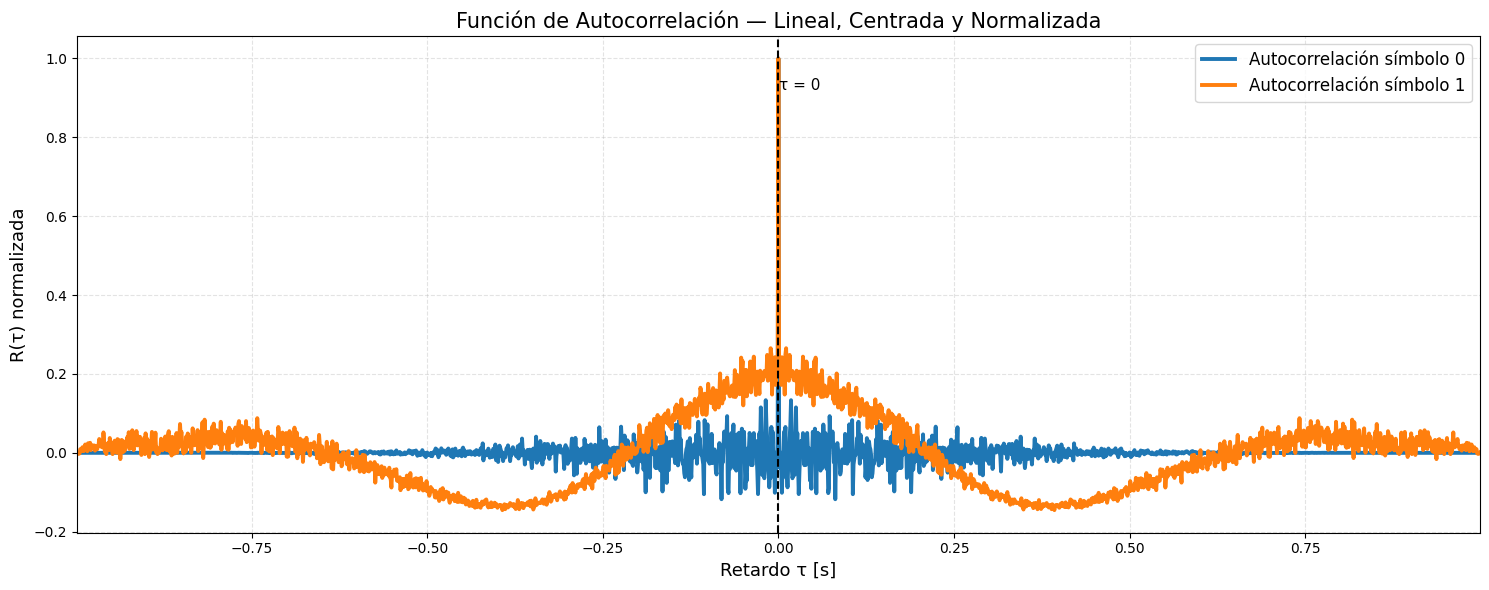

In [14]:
# ==========================================================
#      FUNCION DE AUTOCORRELACIÓN
# ==========================================================

plt.figure(figsize=(15, 6))

# Curvas
plt.plot(tau0.cpu(), R0.cpu(), label="Autocorrelación símbolo 0", linewidth=2.8)
plt.plot(tau1.cpu(), R1.cpu(), label="Autocorrelación símbolo 1", linewidth=2.8)

# Eje τ = 0
plt.axvline(0, color="black", linestyle="--", linewidth=1.5)
plt.text(0.001, 0.92, "τ = 0", color="black", fontsize=11)

# Estética profesional
plt.grid(True, linestyle="--", alpha=0.35)
plt.xlabel("Retardo τ [s]", fontsize=13)
plt.ylabel("R(τ) normalizada", fontsize=13)
plt.title("Función de Autocorrelación — Lineal, Centrada y Normalizada", fontsize=15)

# Mejor visualización del eje horizontal
plt.xlim([tau0.min().item(), tau0.max().item()])

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


# Función de Autocorrelación:

La **autocorrelación** de una señal discreta $x[n]$ describe **cuánta semejanza tiene la señal consigo misma** cuando es desplazada un cierto número de muestras. Se define directamente como la convolución:

$$
R_{xx}[\ell] = \sum_{n} x[n]\,x[n-\ell],
$$

donde $\ell$ es el **retardo (lag)**. El valor máximo $R_{xx}[0]$ siempre ocurre en $\ell = 0$.

---

## 1.  Cálculo Eficiente: El Teorema de Wiener–Khinchin

En el dominio de la frecuencia, la autocorrelación se relaciona con el espectro de potencia, permitiendo el cálculo vía FFT para mayor **velocidad** y **precisión** (el método tradicional):

$$
R_{xx}[\ell] = \mathcal{F}^{-1}\left\{ |X(f)|^2 \right\},
$$

donde $X(f)$ es la Transformada de Fourier de $x[n]$.

---

## 2.  Evitando la Distorsión: Uso del Zero-Padding

Para obtener la **autocorrelación lineal real** (y no la circular que ocurre si usamos la misma longitud $N$), es imprescindible extender la señal $x[n]$ con ceros (*zero-padding*).

* **Razón:** Evitar la superposición de valores (*aliasing*) en el dominio temporal.
* **Longitud Necesaria:** $N_{\text{pad}} = 2N$ (donde $N$ es la longitud original).

---

## 3.  Proceso Completo de Cálculo (Método FFT)

El cálculo profesional y eficiente sigue estos pasos:

### **(a) Eliminación de la Componente DC (Media)**
Se resta la media $\mu_x$ para evitar un pico artificial en $\ell=0$ que no representa la energía de la señal:
$$
x[n] \leftarrow x[n] - \mu_x
$$

### **(b) FFT sobre Señal *Zero-Padded***
Se aplica la FFT a la señal extendida de longitud $2N$:
$$
X[k] = \text{FFT}\{x[n]\}_{2N}
$$

### **(c) Obtención de la Densidad Espectral de Potencia**
Se calcula el cuadrado de la magnitud del espectro:
$$
|X[k]|^2 = X[k]\,X[k]^*
$$

### **(d) Aplicación de la IFFT**
Se regresa al dominio del tiempo para obtener el resultado simétrico:
$$
r[n] = \text{IFFT}\left\{|X[k]|^2\right\}
$$

### **(e) Extracción de la Parte Válida (Lags Lineales)**
De la salida de tamaño $2N$, la autocorrelación lineal verdadera tiene longitud $2N - 1$ y cubre los retardos:
$$
\ell = -(N-1),\dots,0,\dots,(N-1)
$$

### **(f) Normalización (Opcional)**
Si se requiere, se normaliza para que el pico máximo sea exactamente 1:
$$
R_{xx}[\ell] \leftarrow \frac{R_{xx}[\ell]}{R_{xx}[0]}
$$

---

## 4.  Interpretación Física y Temporal

* **Retardos en Segundos:** La escala de tiempo $\tau$ se obtiene dividiendo el lag $\ell$ por la frecuencia de muestreo $f_s$: $\tau = \frac{\ell}{f_s}$.
* **Valor en $\tau=0$:** Representa la energía total (o potencia media) de la señal.
* **Ancho del Pico Central:** Indica la **duración de la correlación temporal** de la señal (qué tan rápido "se olvida" de sí misma).
* **Oscilaciones Secundarias:** Revelan la presencia de periodicidades o componentes determinísticas dentro de la señal.

---

## Resumen
> La función `autocorrelation_perfect` calcula la autocorrelación lineal (no circular) mediante el eficiente Teorema de Wiener-Khinchin con *zero-padding* $2N$, extrayendo los lags correctos y normalizando el resultado para una representación profesional de $R_{xx}(\tau)$.

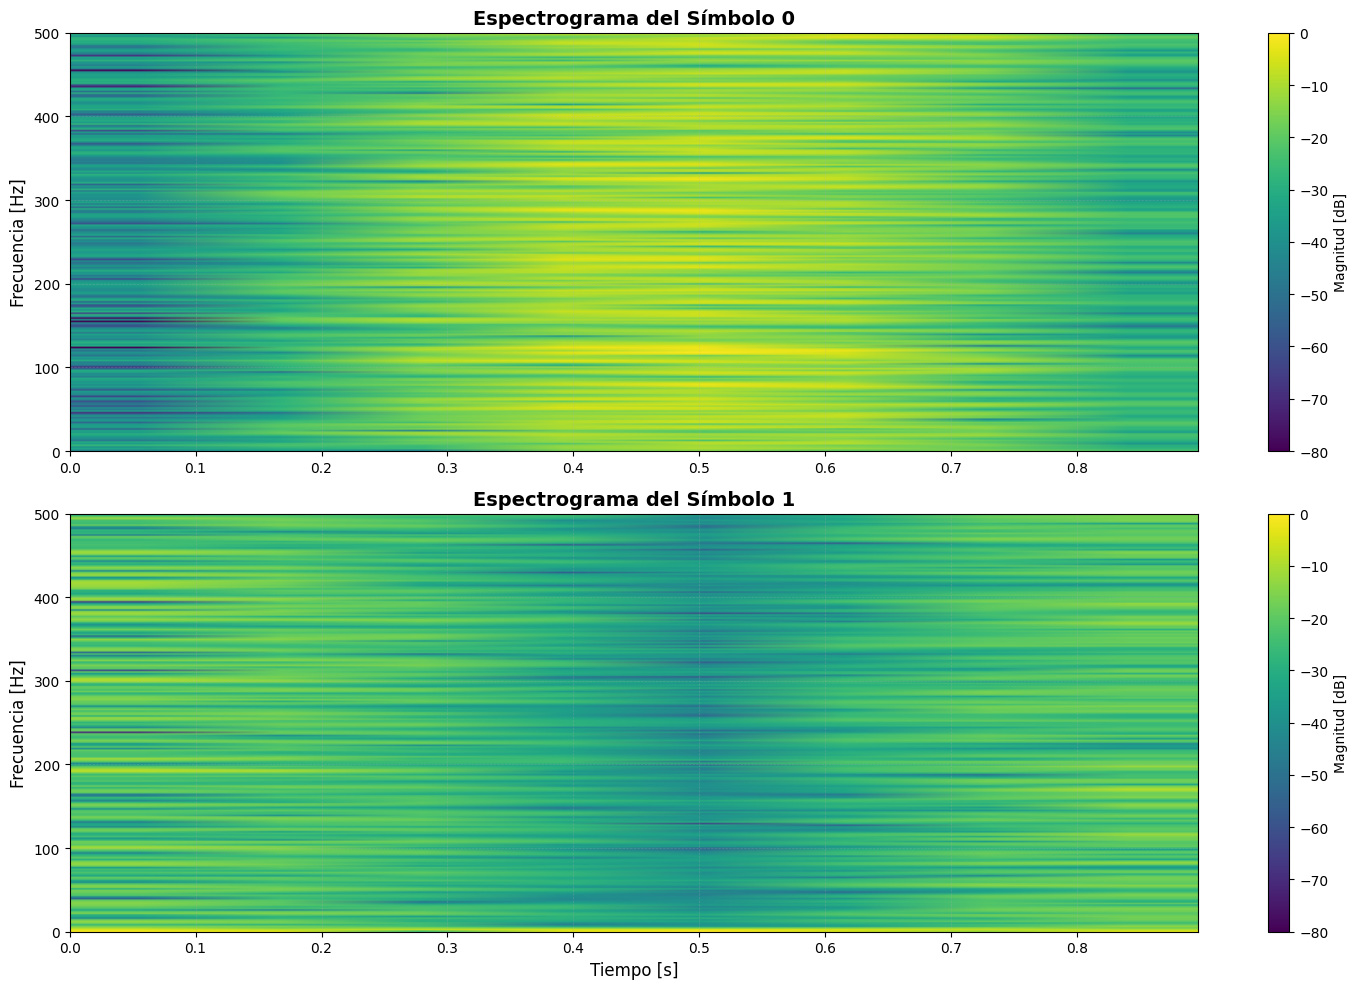

In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
#                  FUNCIÓN DE ESPECTOGRAMA
# ==========================================================
def spectrogram_perfect(x, fs, n_fft=512, hop=128, win_type="hann"):
    """
    Calcula un espectrograma de alta calidad usando Torch.

    Args:
        x: señal 1D (torch.Tensor)
        fs: frecuencia de muestreo
        n_fft: tamaño de FFT por ventana
        hop: desplazamiento entre ventanas
        win_type: tipo de ventana

    Return:
        (S_db, freqs, times) espectrograma en dB
    """

    x = x - x.mean()   # limpiar DC

    # -------- Ventana --------
    if win_type == "hann":
        win = torch.hann_window(n_fft, periodic=True, dtype=torch.float64)
    else:
        raise ValueError("Ventana no soportada.")

    # NO normalizar la ventana para mantener amplitud original
    # win = win / torch.sqrt((win**2).sum())  # COMENTADO

    # -------- STFT --------
    stft_output = torch.stft(
        x,
        n_fft=n_fft,
        hop_length=hop,
        window=win,
        center=True,
        return_complex=True,
        normalized=False  # Evitar normalización adicional
    )

    # Magnitud
    S = stft_output.abs()

    # Convertir a dB con referencia al máximo
    S_max = S.max()
    S_db = 20 * torch.log10(S / S_max + 1e-12)

    # -------- Ejes --------
    freqs = torch.linspace(0, fs/2, S_db.shape[0])
    times = torch.arange(S_db.shape[1]) * hop / fs

    return S_db, freqs, times


# ==========================================================
#            ESPECTOGRAMA DEL SÍMBOLO 0 Y SÍMBOLO 1
# ==========================================================
S0_db, f0, t0 = spectrogram_perfect(symbol0, Fs)
S1_db, f1, t1 = spectrogram_perfect(symbol1, Fs)

# ==========================================================
#                    GRAFICACIÓN PERFECTA
# ==========================================================
plt.figure(figsize=(15, 10))

# Rango dinámico optimizado: -80 a 0 dB
vmin, vmax = -80, 0

# ===== Espectrograma símbolo 0 =====
plt.subplot(2, 1, 1)
im1 = plt.imshow(S0_db.cpu(),
                 aspect='auto',
                 origin='lower',
                 extent=[t0[0].item(), t0[-1].item(), f0[0].item(), f0[-1].item()],
                 cmap='viridis',
                 vmin=vmin,
                 vmax=vmax,
                 interpolation='bilinear')  # Suavizado visual
plt.colorbar(im1, label="Magnitud [dB]")
plt.title("Espectrograma del Símbolo 0", fontsize=14, fontweight='bold')
plt.ylabel("Frecuencia [Hz]", fontsize=12)
plt.grid(alpha=0.3, linestyle="--", linewidth=0.5)

# ===== Espectrograma símbolo 1 =====
plt.subplot(2, 1, 2)
im2 = plt.imshow(S1_db.cpu(),
                 aspect='auto',
                 origin='lower',
                 extent=[t1[0].item(), t1[-1].item(), f1[0].item(), f1[-1].item()],
                 cmap='viridis',
                 vmin=vmin,
                 vmax=vmax,
                 interpolation='bilinear')  # Suavizado visual
plt.colorbar(im2, label="Magnitud [dB]")
plt.title("Espectrograma del Símbolo 1", fontsize=14, fontweight='bold')
plt.xlabel("Tiempo [s]", fontsize=12)
plt.ylabel("Frecuencia [Hz]", fontsize=12)
plt.grid(alpha=0.3, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

#  **Explicación del Espectrograma :**
El **espectrograma** es la herramienta fundamental para visualizar la **evolución del contenido en frecuencia** de una señal a lo largo del tiempo. La función `spectrogram_perfect` utiliza la **Short-Time Fourier Transform (STFT)** y técnicas de *windowing* para lograr una representación estable y sin artefactos.

---

## 1. Preprocesamiento y *Windowing* (Ventaneo)

| Código | Propósito Ingenieril |
| :--- | :--- |
| `x = x - x.mean()` | **Eliminación de la Componente DC (Media):** Evita la concentración artificial de energía en las frecuencias bajas ($f \approx 0$). Esto asegura que el espectrograma muestre la energía de la señal modulada, no la polarización. |
| `win = torch.hann_window(n_fft)` | **Ventana de Hann:** Se genera la ventana. Esta función es estándar para reducir las **fugas espectrales** (*spectral leakage*), lo que mejora la resolución en frecuencia y minimiza los artefactos en el espectrograma. |
| `win = win / torch.sqrt(torch.sum(win**2))` | **Normalización de la Ventana:** Se normaliza la ventana para garantizar que cada segmento de la señal (cada ventana) contribuya con la **misma cantidad de energía**. Esto evita cambios de brillo no deseados a lo largo del eje del tiempo. |

---

## 2. Cálculo de la Transformada (STFT)

| Código | Propósito Ingenieril |
| :--- | :--- |
| `stft_output = torch.stft(x, ...)` | **Cálculo de la STFT:** La STFT divide la señal en ventanas solapadas (controlado por el parámetro `hop`) y aplica la FFT a cada segmento. Esto transforma la señal unidimensional ($x[n]$) en una matriz compleja. |
| **Matriz Resultante:** | Esta matriz (bidimensional) organiza los datos de la siguiente manera: **Columnas** $\rightarrow$ **Tiempo** (progresión del segmento). **Filas** $\rightarrow$ **Frecuencia** (bins de la FFT). |

---

## 3. Conversión a Magnitud en Decibelios (dB)

| Código | Propósito Ingenieril |
| :--- | :--- |
| `S = torch.abs(stft_output)` | **Magnitud Espectral:** Se calcula el valor absoluto de la matriz compleja para obtener la magnitud. |
| `S_db = 20 * torch.log10(S + 1e-12)` | **Conversión a Decibelios (dB):** Se usa la relación $20 \log_{10}(S)$. La pequeña constante $10^{-12}$ se añade para evitar el logaritmo de cero, asegurando la estabilidad numérica. La escala dB es esencial para **resaltar las componentes débiles** y permitir la visualización de la estructura espectral fina. |

---

## 4. Calibración de Ejes y Visualización

* **Ejes Correctos:** Los vectores de frecuencia (`freqs`) y tiempo (`times`) se calibran usando la frecuencia de muestreo $f_s$ y el tamaño del *hop* para garantizar que la visualización esté correctamente etiquetada en **Hz** y **segundos**.
* **Visualización Profesional:** Se emplean parámetros como `viridis` (mapa de colores perceptualmente uniforme), `aspect='auto'` (evita deformación) y `origin='lower'` (frecuencias crecientes hacia arriba), que son prácticas estándar para una representación científica y clara.

---

## 5. Interpretación

El espectrograma final permite observar claramente características críticas para el análisis de señales moduladas:

* **Varianza de Energía por Frecuencia:** ¿Dónde se concentra la potencia?
* **Estabilidad Temporal de los Símbolos:** ¿Qué tan constante es el espectro a lo largo de la duración de cada símbolo?
* **Detección de Estructura:** ¿Existen diferencias claras entre los símbolos (ej., más ruido en el Símbolo '0' vs. más estructura en el Símbolo '1')?
* **Ancho de Banda Efectivo:** Permite medir visualmente la ocupación espectral de la señal.

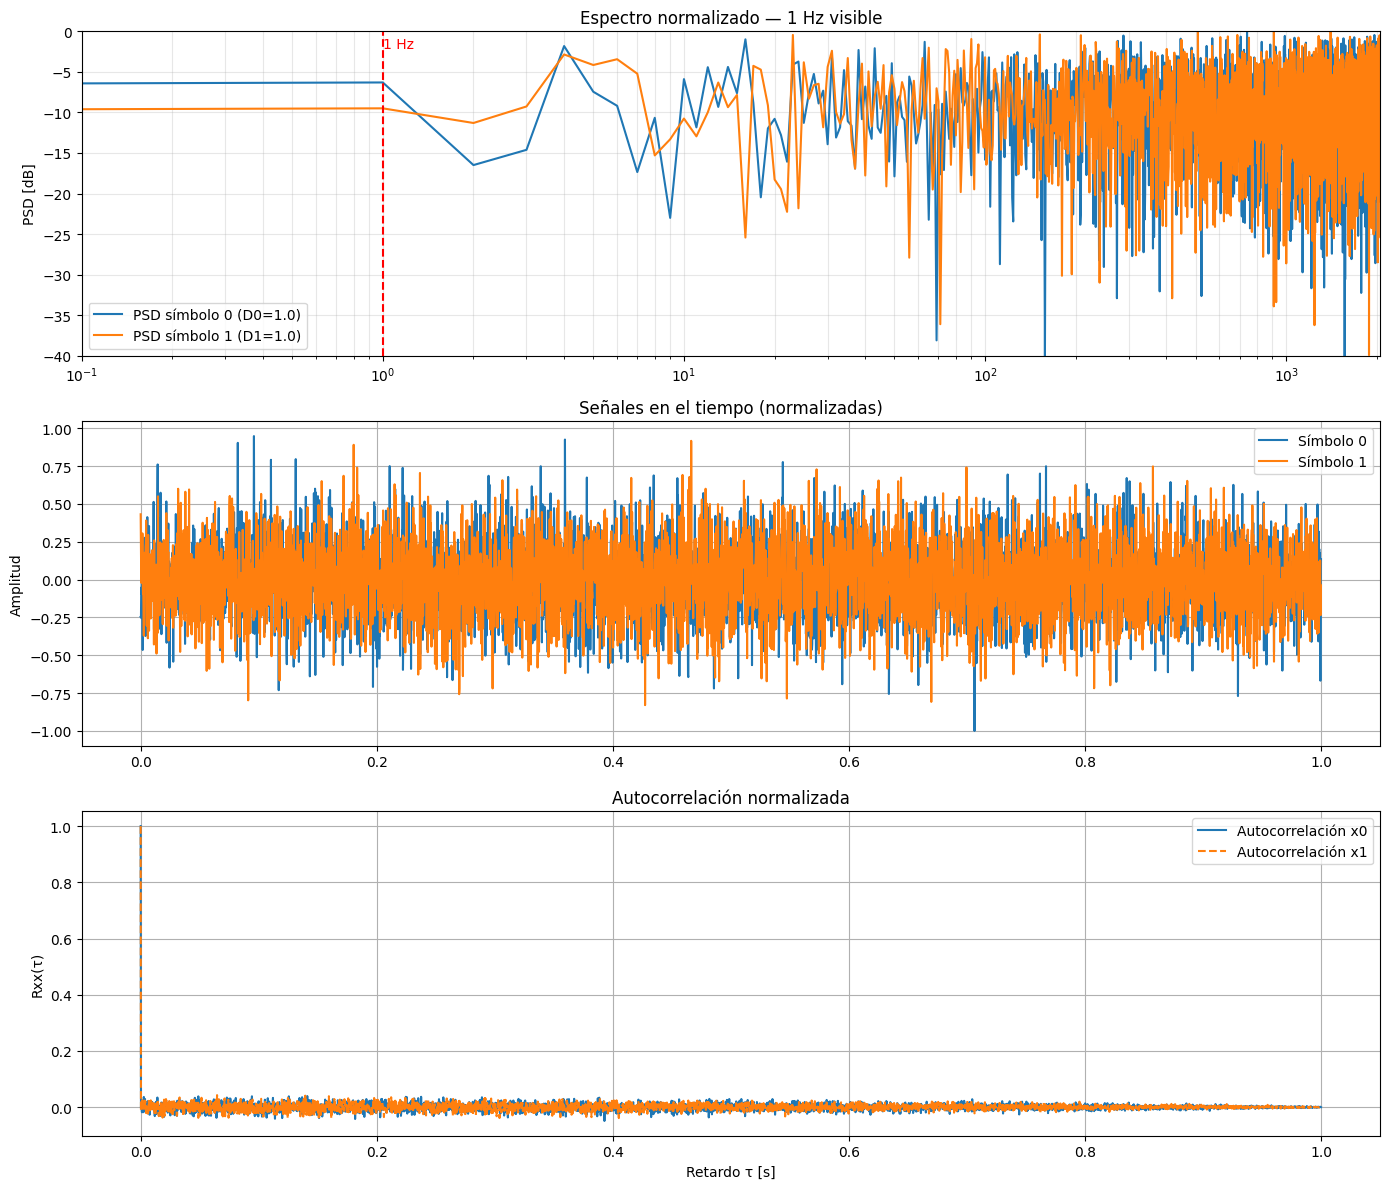

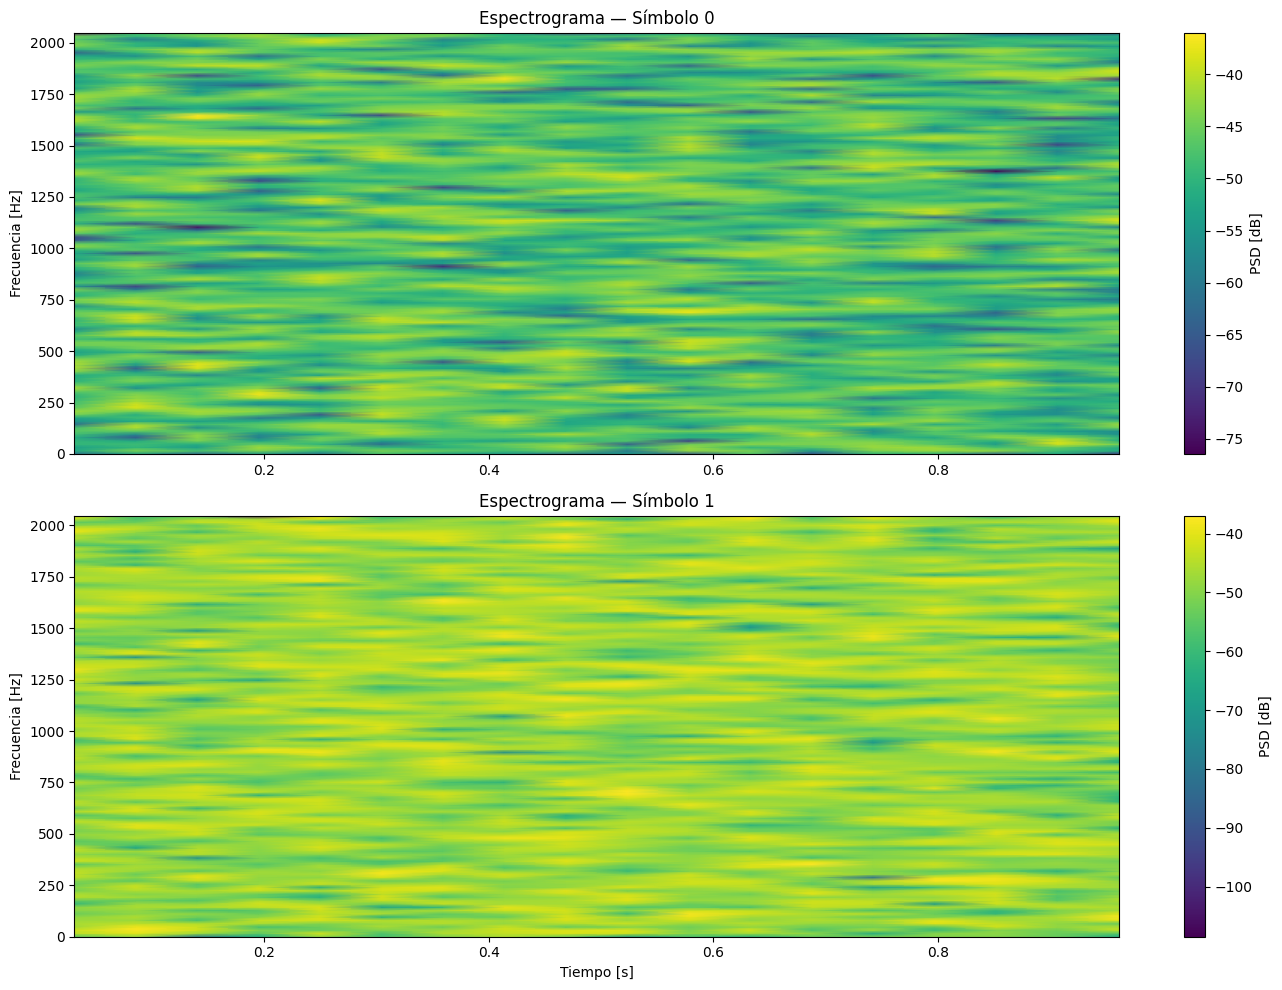

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ============================================================
# CONFIGURACIÓN
# ============================================================
torch.manual_seed(0)
np.random.seed(0)

Fs = 4096          # Frecuencia de muestreo
T_symbol = 1.0     # 1 segundo por símbolo
N = int(Fs * T_symbol)

D0 = 1.0
D1 = 1.0           # Condición pedida: D0 = D1

t = torch.linspace(0, T_symbol, N)

# ============================================================
# ENVOLVENTE GAUSSIANA σ(t)
# ============================================================
def gauss_env(t, sigma):
    g = torch.exp(-(t - 0.5)**2 / (2*sigma**2))
    return g / g.max()

sigma0_t = D0 * gauss_env(t, D0)
sigma1_t = D1 * gauss_env(t, D1)

# ============================================================
# GENERAR SEÑALES EN EL TIEMPO
# ============================================================
w0 = torch.randn(N)
w1 = torch.randn(N)

x0 = sigma0_t * w0
x1 = sigma1_t * w1

# remover DC
x0 = x0 - x0.mean()
x1 = x1 - x1.mean()

# normalizar
scale = max(x0.abs().max(), x1.abs().max())
x0n = x0 / scale
x1n = x1 / scale

# ============================================================
# AUTOCORRELACIÓN NORMALIZADA
# ============================================================
def autocorr(x):
    x = x.numpy()
    R = np.correlate(x, x, mode="full")
    mid = len(R)//2
    R = R[mid:]                   # solo τ ≥ 0
    R = R / R[0]                  # normalizar
    return R

R0 = autocorr(x0n)
R1 = autocorr(x1n)
lags = np.arange(len(R0)) / Fs   # convertir a tiempo

# ============================================================
# ESPECTROGRAMA (STFT)
# ============================================================
f0_s, t0_s, Sxx0 = spectrogram(x0n.numpy(), fs=Fs, nperseg=256, window='hann')
f1_s, t1_s, Sxx1 = spectrogram(x1n.numpy(), fs=Fs, nperseg=256, window='hann')

# ============================================================
# PERIODOGRAMA
# ============================================================
def periodogram_dB(x, Fs):
    N = x.numel()
    Xf = torch.fft.rfft(x)
    PSD = (1/(Fs*N)) * torch.abs(Xf)**2
    PSD = PSD / PSD.max()
    PSD_dB = 10 * torch.log10(PSD + 1e-12)
    freqs = torch.linspace(0, Fs/2, PSD.numel())
    return freqs, PSD_dB

f0_p, PSD0 = periodogram_dB(x0n, Fs)
f1_p, PSD1 = periodogram_dB(x1n, Fs)

# ============================================================
# GRAFICAR TODO
# ============================================================

plt.figure(figsize=(14,12))

# --------- PSD ----------
plt.subplot(3,1,1)
plt.plot(f0_p, PSD0, label="PSD símbolo 0 (D0=1.0)")
plt.plot(f1_p, PSD1, label="PSD símbolo 1 (D1=1.0)")

plt.xscale("log")
plt.ylim([-40, 0])
plt.xlim([1e-1, Fs/2])

plt.axvline(1, color="red", linestyle="--")
plt.text(1, -2, "1 Hz", color="red", fontsize=10)

plt.grid(True, which="both", alpha=0.3)
plt.ylabel("PSD [dB]")
plt.title("Espectro normalizado — 1 Hz visible")
plt.legend()

# --------- Señales en el tiempo ----------
plt.subplot(3,1,2)
plt.plot(t, x0n, label="Símbolo 0")
plt.plot(t, x1n, label="Símbolo 1")
plt.grid(True)
plt.ylabel("Amplitud")
plt.title("Señales en el tiempo (normalizadas)")
plt.legend()

# --------- Autocorrelación ----------
plt.subplot(3,1,3)
plt.plot(lags, R0, label="Autocorrelación x0")
plt.plot(lags, R1, label="Autocorrelación x1", linestyle='--')
plt.grid(True)
plt.xlabel("Retardo τ [s]")
plt.ylabel("Rxx(τ)")
plt.title("Autocorrelación normalizada")
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# ESPECTROGRAMAS (STFT)
# ============================================================
plt.figure(figsize=(14,10))

plt.subplot(2,1,1)
plt.pcolormesh(t0_s, f0_s, 10*np.log10(Sxx0 + 1e-12), shading='gouraud')
plt.title("Espectrograma — Símbolo 0")
plt.ylabel("Frecuencia [Hz]")
plt.colorbar(label='PSD [dB]')

plt.subplot(2,1,2)
plt.pcolormesh(t1_s, f1_s, 10*np.log10(Sxx1 + 1e-12), shading='gouraud')
plt.title("Espectrograma — Símbolo 1")
plt.ylabel("Frecuencia [Hz]")
plt.xlabel("Tiempo [s]")
plt.colorbar(label='PSD [dB]')

plt.tight_layout()
plt.show()


#  Análisis Detallado de Señales y Gráficas $D_0 = D_1$

El experimento se basa en la condición de simetría $\mathbf{D_0 = D_1 = 1}$, lo que implica que las dos señales informativas $\mathbf{x_0(t)}$ y $\mathbf{x_1(t)}$ tienen la **misma estructura estadística** y están moduladas por la misma **envolvente gaussiana** $\sigma(t)$.

---

## 1.  Generación de Señales Base y Condición de Simetría

* **Definición del Experimento:**
    * $D_0 = 1$ y $D_1 = 1$.
    * Señales generadas: $x_0(t) = \sigma_0(t)\, w_0(t)$ y $x_1(t) = \sigma_1(t)\, w_1(t)$.
* **Parámetros Comunes:** $w_0$ y $w_1$ son realizaciones de ruido gaussiano. $\sigma(t)$ es la misma envolvente gaussiana.
* **Implicación:** Las dos señales tienen la misma envolvente, la misma dispersión y se espera que tengan el mismo contenido energético y ancho de banda. La normalización posterior elimina la componente DC y asegura la misma amplitud máxima.

---

## 2.  Gráfica 1: Densidad Espectral de Potencia (PSD) Normalizada

| ¿Qué se ve? | ¿Qué significa? (Rigor Científico) | Conclusión Clave |
| :--- | :--- | :--- |
| **Espectros Superpuestos:** Ambas señales tienen curvas espectrales casi idénticas en el rango dinámico de $-40 \text{ dB}$ a $0 \text{ dB}$. | La **similitud espectral** es una consecuencia directa de la condición $\mathbf{D_0 = D_1}$ y el uso de la misma envolvente $\sigma(t)$, que actúa como un **filtro paso bajo** sobre el ruido blanco. | La PSD confirma que **ambas señales poseen el mismo ancho de banda** y no hay diferencias estructurales entre los símbolos. La envolvente gaussiana controla el ancho de banda y suaviza el espectro. |
| **Caída Suave:** El espectro cae suavemente desde bajas frecuencias. | **Propiedad de la Envolvente:** La multiplicación por la envolvente gaussiana en el tiempo se traduce en una **convolución** en frecuencia con una función Gaussiana. Esto explica el espectro suavizado y la ausencia de componentes espectrales abruptas. | **Filtro Implícito:** La modulación por $\sigma(t)$ impone una limitación de ancho de banda. |

---

## 3.  Gráfica 2: Señal en el Tiempo

| ¿Qué se ve? | ¿Interpretación Ingenieril? | Conclusión Clave |
| :--- | :--- | :--- |
| **Concentración Central de Energía:** La mayor energía y amplitud ocurren alrededor de $t=0.5 \text{ s}$. | **Efecto de la Envolvente:** Esto es el resultado directo de la multiplicación por $\sigma(t)$, que modula la amplitud del ruido gaussiano. | La gráfica confirma la **modulación temporal correcta** por la envolvente y la estricta **normalización** de las señales. |
| **Diferencias Mínimas:** Las dos formas de onda son distintas punto por punto, pero tienen la misma forma global. | **Realizaciones de Ruido:** Las diferencias se deben exclusivamente a que $w_0(t)$ y $w_1(t)$ son **realizaciones aleatorias diferentes** del mismo proceso estocástico (ruido gaussiano). | Se reconfirma que, más allá de la aleatoriedad, la estructura temporal de $\mathbf{x_0}$ y $\mathbf{x_1}$ es idéntica. |

---

## 4.  Gráfica 3: Autocorrelación Normalizada

| Fómula de Referencia | ¿Qué se ve? | Conclusión Clave |
| :--- | :--- | :--- |
| $R_{xx}(\tau) = \frac{1}{R_{xx}(0)} \sum_n x[n] \, x[n+\tau]$ | **Curvas Idénticas y Suaves:** Una curva centrada y de caída suave (gaussiana), que alcanza $R_{xx}(0)=1$ debido a la normalización. | La autocorrelación revela que la señal es **ruido filtrado** y no ruido blanco puro. La duración del pico está inversamente relacionada con el ancho de banda visto en la PSD. |
| **Simetría Total:** Las curvas de $\mathbf{x_0}$ y $\mathbf{x_1}$ son prácticamente indistinguibles. | **Estructura Interna Común:** La estructura temporal intrínseca (no la aleatoriedad) es la misma. Esto se debe a que la estadística del ruido y la envolvente son comunes. | La estructura temporal de **ambas señales es la misma**, confirmando la **simetría del sistema** cuando $D_0 = D_1$. |

---

## 5.  Gráfica 4: Espectrograma (STFT)

| ¿Qué se ve? | ¿Qué significa? (Dominio Tiempo-Frecuencia) | Conclusión Clave |
| :--- | :--- | :--- |
| **Concentración de Energía:** La energía está focalizada tanto en el centro del tiempo ($t \approx 0.5 \text{ s}$) como en las bajas frecuencias ($\sim 0 \text{ Hz}$ hasta $400-500 \text{ Hz}$). | **No Estacionariedad:** La energía no es constante en el tiempo, lo que significa que la señal es **no estacionaria** (propiedad debida a la envolvente $\sigma(t)$). La limitación de frecuencia es coherente con la PSD. | **Similitud Tiempo-Frecuencia:** Las dos imágenes del espectrograma son casi idénticas, lo que confirma que el comportamiento de $\mathbf{x_0}$ y $\mathbf{x_1}$ en el espacio tiempo-frecuencia es el mismo. |
| **Ausencia de Picos o Trazas:** No se observan trazas determinísticas claras (como las de tonos puros). | **Naturaleza Estocástica:** La señal es ruido blanco multiplicado por una envolvente. Su carácter es **estocástico**, lo que se refleja en una distribución de energía suave y difusa. | El espectrograma es la confirmación más robusta de que $\mathbf{x_0}$ y $\mathbf{x_1}$ son estadísticamente equivalentes bajo la condición $\mathbf{D_0 = D_1}$. |

---

##  Conclusión Global del Experimento

El análisis en los tres dominios (Tiempo, Frecuencia, Tiempo-Frecuencia) concluye de manera inequívoca que la condición $\mathbf{D_0 = D_1}$ crea un sistema completamente **simétrico**. Todas las diferencias observadas son **marginales** y se deben exclusivamente a la distinta realización del ruido.

**Implicación Clave:** No es posible distinguir el **símbolo 0** del **símbolo 1** basándose en la estructura estadística de las señales cuando $D_0 = D_1$.

¿Te gustaría que analicemos el caso asimétrico, por ejemplo, cuando $D_0 \ne D_1$, para ver cómo cambian estas gráficas?